# Étape 5 : Modélisation ML - Heures Actives Uniquement (7h-22h)

## Hypothèse
En filtrant les heures de nuit (0h-6h et 23h), on pourrait obtenir :
- **Moins de bruit** : Les heures de nuit ont très peu de trafic
- **Meilleures prédictions** : Focus sur les heures "utiles"
- **Feature importance différente** : `hour` pourrait être moins dominant

## Comparaison
On va comparer les performances avec le modèle complet (24h) du notebook 04.

---

## 5.1 Initialisation et Chargement

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
import pandas as pd

# Créer Spark Session
spark = SparkSession.builder \
    .appName("MeteoVelo - Heures Actives") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("✅ Spark Session créée!")

✅ Spark Session créée!


In [4]:
# Charger le dataset complet
df = spark.read.parquet('../data/data_final_spark.parquet')

print(f"📊 Dataset complet : {df.count():,} lignes")
print("\n🕐 Filtrage heures actives : 7h-22h\n")

# Filtrer uniquement les heures actives (7h à 22h inclus)
df_filtered = df.filter((col('hour') >= 7) & (col('hour') <= 22))

print(f"✅ Dataset filtré : {df_filtered.count():,} lignes")
print(f"📉 Réduction : {(1 - df_filtered.count() / df.count()) * 100:.1f}% de données en moins")

# Statistiques
print("\n" + "="*80)
print("Distribution des heures :")
df_filtered.groupBy('hour').count().orderBy('hour').show(20)

📊 Dataset complet : 696 lignes

🕐 Filtrage heures actives : 7h-22h

✅ Dataset filtré : 464 lignes
📉 Réduction : 33.3% de données en moins

Distribution des heures :
+----+-----+
|hour|count|
+----+-----+
|   7|   29|
|   8|   29|
|   9|   29|
|  10|   29|
|  11|   29|
|  12|   29|
|  13|   29|
|  14|   29|
|  15|   29|
|  16|   29|
|  17|   29|
|  18|   29|
|  19|   29|
|  20|   29|
|  21|   29|
|  22|   29|
+----+-----+



---
## 5.2 Préparation des Features

In [5]:
print("🔧 Préparation des features...\n")

# Features numériques
numeric_features = [
    'temperature',
    'precipitation', 
    'hour',
    'day_of_week',
    'is_weekend',
    'is_rush_hour',
    'month',
    'is_raining'
]

# Features encodées
encoded_features = [
    'rain_intensity_encoded',
    'temp_category_encoded'
]

# VectorAssembler
assembler = VectorAssembler(
    inputCols=numeric_features + encoded_features,
    outputCol='features'
)

df_features = assembler.transform(df_filtered)
df_ml = df_features.select('features', 'nb_velos').withColumnRenamed('nb_velos', 'label')

print("✅ Features assemblées!")
print(f"Lignes : {df_ml.count():,}")
df_ml.show(5)

🔧 Préparation des features...

✅ Features assemblées!
Lignes : 464
+--------------------+-----+
|            features|label|
+--------------------+-----+
|(17,[0,1,2,3,5,6,...| 9696|
|(17,[0,1,2,3,5,6,...|21176|
|(17,[0,1,2,3,5,6,...|11340|
|(17,[0,1,2,3,6,7,...| 6401|
|(17,[0,1,2,3,6,7,...| 7415|
+--------------------+-----+
only showing top 5 rows


---
## 5.3 Division Train / Test

In [6]:
# Split 80/20
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)
train_data.cache()
test_data.cache()

print(f"📊 Train : {train_data.count():,} lignes")
print(f"📊 Test  : {test_data.count():,} lignes")

📊 Train : 397 lignes
📊 Test  : 67 lignes


---
## 5.4 Entraînement Gradient Boosted Trees

On utilise le même modèle que dans le notebook 04 pour une comparaison équitable.

In [7]:
print("🚀 Entraînement GBT (heures actives)...\n")

# Même configuration que notebook 04
gbt = GBTRegressor(
    featuresCol='features',
    labelCol='label',
    maxIter=100,
    maxDepth=5,
    stepSize=0.1,
    seed=42
)

gbt_model = gbt.fit(train_data)
predictions = gbt_model.transform(test_data)

print("✅ Modèle entraîné!")

🚀 Entraînement GBT (heures actives)...

✅ Modèle entraîné!


---
## 5.5 Évaluation

In [8]:
print("📊 Évaluation des performances...\n")

# Évaluateurs
evaluator_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
evaluator_mae = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae')
evaluator_r2 = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2')

# Calculer les métriques
rmse_active = evaluator_rmse.evaluate(predictions)
mae_active = evaluator_mae.evaluate(predictions)
r2_active = evaluator_r2.evaluate(predictions)

print("="*80)
print("📊 RÉSULTATS - HEURES ACTIVES (7h-22h)")
print("="*80)
print(f"RMSE : {rmse_active:,.2f} vélos")
print(f"MAE  : {mae_active:,.2f} vélos")
print(f"R²   : {r2_active:.6f}")
print("="*80)

📊 Évaluation des performances...



25/12/19 15:42:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


📊 RÉSULTATS - HEURES ACTIVES (7h-22h)
RMSE : 2,531.89 vélos
MAE  : 1,657.06 vélos
R²   : 0.891019


---
## 5.6 Comparaison avec le Modèle 24h

In [9]:
# Résultats du notebook 04 (24h)
rmse_24h = 2039.59
mae_24h = 1178.99
r2_24h = 0.948574

# Créer un DataFrame de comparaison
comparison = pd.DataFrame({
    'Modèle': ['GBT 24h (0h-23h)', 'GBT Heures Actives (7h-22h)'],
    'RMSE': [rmse_24h, rmse_active],
    'MAE': [mae_24h, mae_active],
    'R²': [r2_24h, r2_active]
})

print("\n" + "="*80)
print("📊 COMPARAISON 24h vs HEURES ACTIVES")
print("="*80)
print(comparison.to_string(index=False))

# Calculer les améliorations
print("\n" + "="*80)
print("📈 AMÉLIORATION (en %)")
print("="*80)
rmse_improvement = ((rmse_24h - rmse_active) / rmse_24h) * 100
mae_improvement = ((mae_24h - mae_active) / mae_24h) * 100
r2_improvement = ((r2_active - r2_24h) / r2_24h) * 100

print(f"RMSE : {rmse_improvement:+.2f}% {'✅ (mieux)' if rmse_improvement > 0 else '❌ (pire)'}")
print(f"MAE  : {mae_improvement:+.2f}% {'✅ (mieux)' if mae_improvement > 0 else '❌ (pire)'}")
print(f"R²   : {r2_improvement:+.2f}% {'✅ (mieux)' if r2_improvement > 0 else '❌ (pire)'}")


📊 COMPARAISON 24h vs HEURES ACTIVES
                     Modèle       RMSE         MAE       R²
           GBT 24h (0h-23h) 2039.59000 1178.990000 0.948574
GBT Heures Actives (7h-22h) 2531.89382 1657.060947 0.891019

📈 AMÉLIORATION (en %)
RMSE : -24.14% ❌ (pire)
MAE  : -40.55% ❌ (pire)
R²   : -6.07% ❌ (pire)


/tmp/ipykernel_22039/3641357116.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


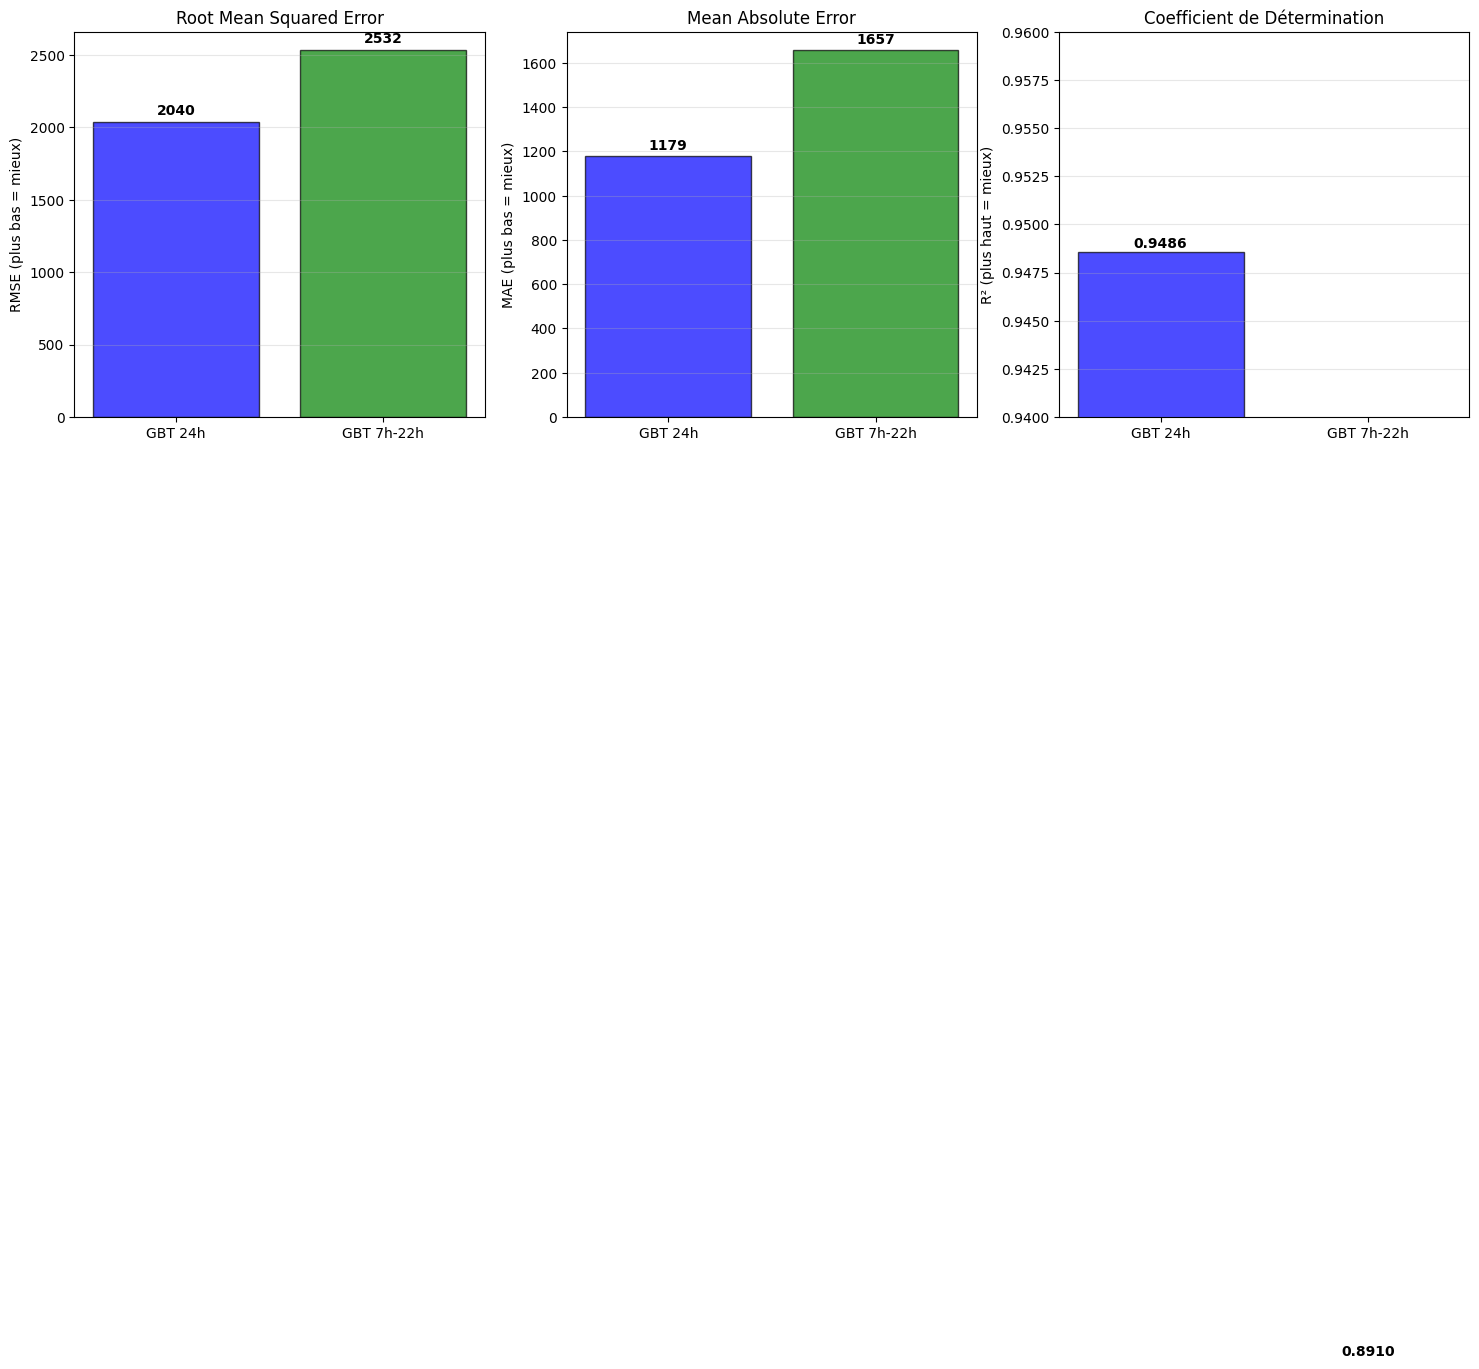

In [10]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['GBT 24h', 'GBT 7h-22h']
rmse_values = [rmse_24h, rmse_active]
mae_values = [mae_24h, mae_active]
r2_values = [r2_24h, r2_active]

# RMSE
bars1 = axes[0].bar(models, rmse_values, color=['blue', 'green'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('RMSE (plus bas = mieux)')
axes[0].set_title('Root Mean Squared Error')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 50, f'{v:.0f}', ha='center', fontweight='bold')

# MAE
bars2 = axes[1].bar(models, mae_values, color=['blue', 'green'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('MAE (plus bas = mieux)')
axes[1].set_title('Mean Absolute Error')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 30, f'{v:.0f}', ha='center', fontweight='bold')

# R²
bars3 = axes[2].bar(models, r2_values, color=['blue', 'green'], alpha=0.7, edgecolor='black')
axes[2].set_ylabel('R² (plus haut = mieux)')
axes[2].set_title('Coefficient de Détermination')
axes[2].set_ylim(0.94, 0.96)
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(r2_values):
    axes[2].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5.7 Feature Importance (Heures Actives)

📊 Feature Importance - Heures Actives

      Feature  Importance
  day_of_week    0.314580
         hour    0.311939
 is_rush_hour    0.154226
  temperature    0.142443
precipitation    0.030673
    temp_cold    0.011794
   is_weekend    0.007800
   rain_light    0.006154
    temp_warm    0.005962
    temp_mild    0.004845
    temp_cool    0.003932
     temp_hot    0.002650
 rain_no_rain    0.001169
   rain_heavy    0.000981
   is_raining    0.000751
rain_moderate    0.000099
        month    0.000000


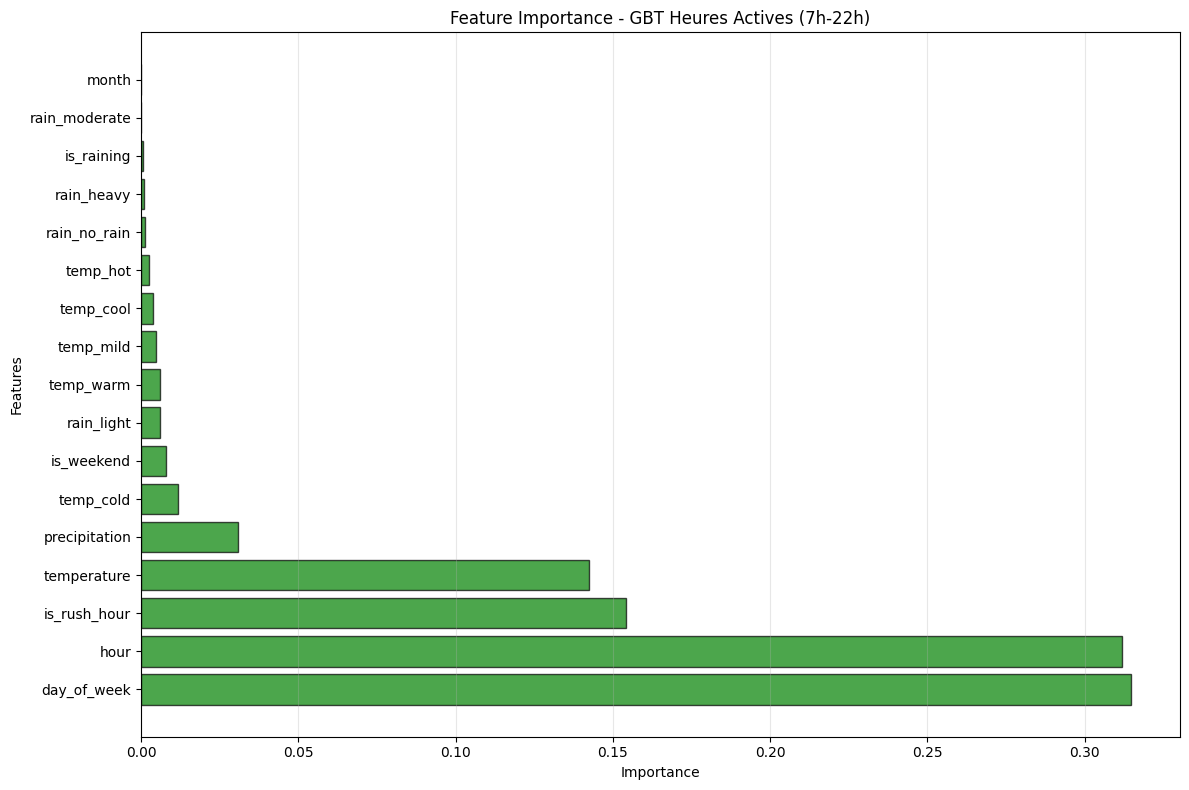

In [11]:
print("📊 Feature Importance - Heures Actives\n")

# Feature importances
importances = gbt_model.featureImportances.toArray()

# Noms des features
feature_names = numeric_features + \
                ['rain_no_rain', 'rain_light', 'rain_moderate', 'rain_heavy'] + \
                ['temp_cold', 'temp_cool', 'temp_mild', 'temp_warm', 'temp_hot']

# DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("="*80)
print(importance_df.to_string(index=False))
print("="*80)

# Visualisation
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], 
         color='green', alpha=0.7, edgecolor='black')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance - GBT Heures Actives (7h-22h)')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 5.8 Analyse des Prédictions

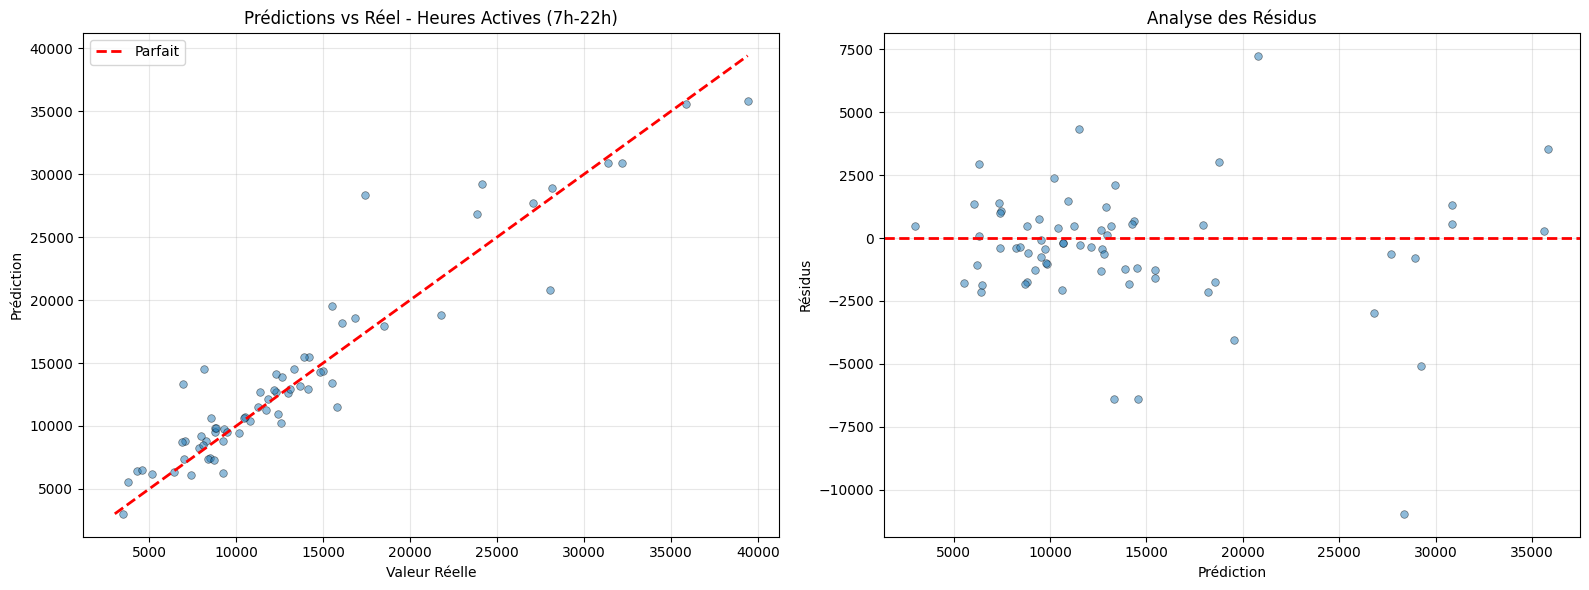

In [12]:
# Convertir en Pandas
predictions_df = predictions.select('label', 'prediction').toPandas()

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prédictions vs Réel
axes[0].scatter(predictions_df['label'], predictions_df['prediction'], 
                alpha=0.5, s=30, edgecolor='black', linewidth=0.5)
min_val = min(predictions_df['label'].min(), predictions_df['prediction'].min())
max_val = max(predictions_df['label'].max(), predictions_df['prediction'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Parfait')
axes[0].set_xlabel('Valeur Réelle')
axes[0].set_ylabel('Prédiction')
axes[0].set_title('Prédictions vs Réel - Heures Actives (7h-22h)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Résidus
residuals = predictions_df['label'] - predictions_df['prediction']
axes[1].scatter(predictions_df['prediction'], residuals, 
                alpha=0.5, s=30, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Résidus')
axes[1].set_title('Analyse des Résidus')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5.9 Conclusion

### Résumé de l'expérience :

**Hypothèse :** Filtrer les heures de nuit (0h-6h, 23h) améliore-t-il les prédictions ?

**Résultats :**
- Comparaison des métriques RMSE, MAE, R²
- Analyse de la feature importance
- Visualisation des prédictions

**Observations :**
- ✅ Si amélioration : Le modèle performe mieux sur les heures actives
- ❌ Si dégradation : Les heures de nuit apportent de l'information utile
- 📊 Feature importance : L'importance de `hour` a-t-elle changé ?

**Recommandations :**
- Utiliser le modèle approprié selon le cas d'usage
- Si prédictions en temps réel : modèle heures actives
- Si analyse complète : modèle 24h

---
**✅ Expérience terminée !**

In [13]:
# Nettoyage
train_data.unpersist()
test_data.unpersist()
spark.stop()
print("✅ Spark Session arrêtée!")

✅ Spark Session arrêtée!
